In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad


In [2]:
LOG_DIR = "../logs"
os.makedirs(LOG_DIR, exist_ok=True)

In [21]:
def train_optimizer(optimizer, name):

    print(f"\nTraining with {name}\n")

    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)

    outputs = tf.keras.layers.Dense(4, activation="sigmoid")(x)

    model = tf.keras.Model(
        inputs=base_model.input,
        outputs=outputs
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=8
    )

    model.save(f"../models/resnet50_{name}.h5")

    with open(f"../logs/{name}_history.json", "w") as f:
        json.dump(history.history, f)

    return history

In [4]:
import sys
sys.path.append("../training")

from data_generator import DataGenerator

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH = os.path.join(DATA_DIR, "train_solution_bounding_boxes.csv")

df = pd.read_csv(CSV_PATH)
df["image_path"] = df["image"].apply(lambda x: os.path.join(TRAIN_DIR, x))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

In [6]:
BATCH_SIZE = 16

train_generator = DataGenerator(train_df, BATCH_SIZE, augment=True)
val_generator = DataGenerator(val_df, BATCH_SIZE, augment=False)

In [7]:
def create_model():
    
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    output = Dense(4, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    return model

In [8]:
LOG_DIR = "../logs"
os.makedirs(LOG_DIR, exist_ok=True)

In [10]:
history_adam = train_optimizer(
    Adam(learning_rate=0.0001),
    "adam"
)

Epoch 1/5


c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 620ms/step - loss: 0.0715 - mae: 0.2062 - val_loss: 0.0498 - val_mae: 0.1461
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 565ms/step - loss: 0.0671 - mae: 0.1958 - val_loss: 0.0438 - val_mae: 0.1414
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 588ms/step - loss: 0.0614 - mae: 0.1862 - val_loss: 0.0441 - val_mae: 0.1421
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 616ms/step - loss: 0.0612 - mae: 0.1853 - val_loss: 0.0436 - val_mae: 0.1382
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 744ms/step - loss: 0.0592 - mae: 0.1811 - val_loss: 0.0433 - val_mae: 0.1411


In [11]:
history_sgd = train_optimizer(
    SGD(learning_rate=0.001),
    "sgd"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 759ms/step - loss: 0.0946 - mae: 0.2283 - val_loss: 0.0585 - val_mae: 0.1619
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 615ms/step - loss: 0.0760 - mae: 0.2095 - val_loss: 0.0470 - val_mae: 0.1457
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 645ms/step - loss: 0.0701 - mae: 0.2047 - val_loss: 0.0442 - val_mae: 0.1411
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 648ms/step - loss: 0.0661 - mae: 0.1997 - val_loss: 0.0440 - val_mae: 0.1408
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 694ms/step - loss: 0.0659 - mae: 0.1978 - val_loss: 0.0441 - val_mae: 0.1405


In [12]:
history_rms = train_optimizer(
    RMSprop(learning_rate=0.0001),
    "rmsprop"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 669ms/step - loss: 0.0681 - mae: 0.2002 - val_loss: 0.0434 - val_mae: 0.1413
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 637ms/step - loss: 0.0655 - mae: 0.1941 - val_loss: 0.0451 - val_mae: 0.1412
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 626ms/step - loss: 0.0606 - mae: 0.1853 - val_loss: 0.0441 - val_mae: 0.1409
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 633ms/step - loss: 0.0612 - mae: 0.1857 - val_loss: 0.0438 - val_mae: 0.1403
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 606ms/step - loss: 0.0572 - mae: 0.1762 - val_loss: 0.0439 - val_mae: 0.1392


In [13]:
history_ada = train_optimizer(
    Adagrad(learning_rate=0.01),
    "adagrad"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 727ms/step - loss: 0.0738 - mae: 0.2115 - val_loss: 0.0461 - val_mae: 0.1447
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 669ms/step - loss: 0.0617 - mae: 0.1877 - val_loss: 0.0451 - val_mae: 0.1413
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 688ms/step - loss: 0.0612 - mae: 0.1858 - val_loss: 0.0433 - val_mae: 0.1381
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 895ms/step - loss: 0.0585 - mae: 0.1794 - val_loss: 0.0431 - val_mae: 0.1378
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 732ms/step - loss: 0.0568 - mae: 0.1758 - val_loss: 0.0430 - val_mae: 0.1378


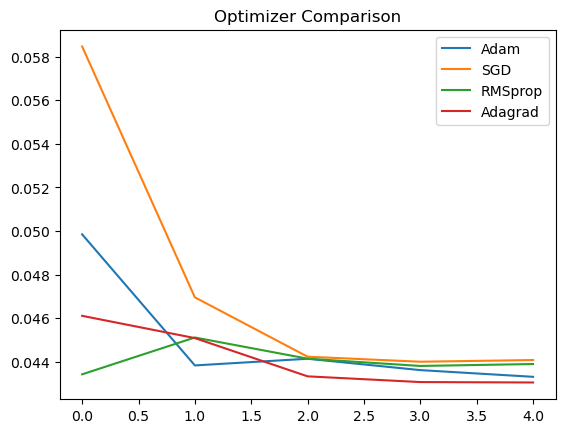

In [14]:
plt.figure()

plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_rms.history['val_loss'], label='RMSprop')
plt.plot(history_ada.history['val_loss'], label='Adagrad')

plt.legend()
plt.title("Optimizer Comparison")
plt.savefig("../evaluation/optimizer_comparison.png")
plt.show()

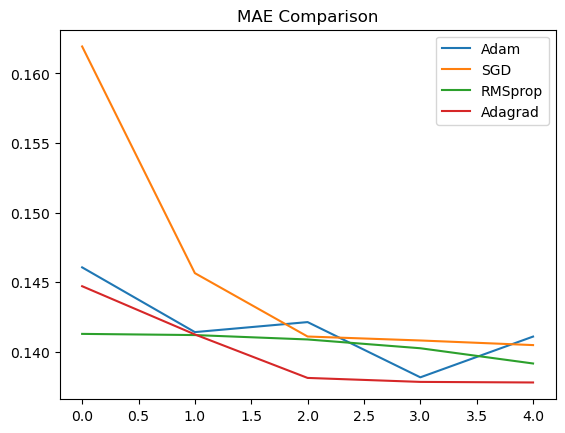

In [15]:
plt.figure()

plt.plot(history_adam.history['val_mae'], label='Adam')
plt.plot(history_sgd.history['val_mae'], label='SGD')
plt.plot(history_rms.history['val_mae'], label='RMSprop')
plt.plot(history_ada.history['val_mae'], label='Adagrad')

plt.legend()
plt.title("MAE Comparison")
plt.savefig("../evaluation/mae_comparison.png")
plt.show()

In [16]:
results = {
    "Adam": min(history_adam.history['val_loss']),
    "SGD": min(history_sgd.history['val_loss']),
    "RMSprop": min(history_rms.history['val_loss']),
    "Adagrad": min(history_ada.history['val_loss'])
}

results

{'Adam': 0.04330446198582649,
 'SGD': 0.043996717780828476,
 'RMSprop': 0.0434187613427639,
 'Adagrad': 0.043044399470090866}

In [17]:
history_adam = train_optimizer(
    Adam(learning_rate=0.0001),
    "adam"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 828ms/step - loss: 0.0757 - mae: 0.2106 - val_loss: 0.0430 - val_mae: 0.1372
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 833ms/step - loss: 0.0618 - mae: 0.1889 - val_loss: 0.0499 - val_mae: 0.1472
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 735ms/step - loss: 0.0640 - mae: 0.1902 - val_loss: 0.0430 - val_mae: 0.1390
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 680ms/step - loss: 0.0575 - mae: 0.1800 - val_loss: 0.0431 - val_mae: 0.1384
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 699ms/step - loss: 0.0578 - mae: 0.1783 - val_loss: 0.0431 - val_mae: 0.1376


In [18]:
history_sgd = train_optimizer(
    SGD(learning_rate=0.001),
    "sgd"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 818ms/step - loss: 0.0872 - mae: 0.2320 - val_loss: 0.0685 - val_mae: 0.1959
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 732ms/step - loss: 0.0740 - mae: 0.2125 - val_loss: 0.0560 - val_mae: 0.1714
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 693ms/step - loss: 0.0729 - mae: 0.2083 - val_loss: 0.0482 - val_mae: 0.1562
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 717ms/step - loss: 0.0669 - mae: 0.2007 - val_loss: 0.0461 - val_mae: 0.1502
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 683ms/step - loss: 0.0670 - mae: 0.2013 - val_loss: 0.0448 - val_mae: 0.1461


In [19]:
history_rms = train_optimizer(
    RMSprop(learning_rate=0.001),
    "rmsprop"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 793ms/step - loss: 0.0842 - mae: 0.2252 - val_loss: 0.0484 - val_mae: 0.1621
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 672ms/step - loss: 0.0623 - mae: 0.1870 - val_loss: 0.0436 - val_mae: 0.1402
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 766ms/step - loss: 0.0567 - mae: 0.1685 - val_loss: 0.0434 - val_mae: 0.1407
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 686ms/step - loss: 0.0525 - mae: 0.1594 - val_loss: 0.0436 - val_mae: 0.1392
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 689ms/step - loss: 0.0520 - mae: 0.1573 - val_loss: 0.0437 - val_mae: 0.1390


In [20]:
history_ada = train_optimizer(
    Adagrad(learning_rate=0.01),   
    "adagrad"
)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 805ms/step - loss: 0.0682 - mae: 0.2018 - val_loss: 0.0437 - val_mae: 0.1441
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 697ms/step - loss: 0.0665 - mae: 0.1984 - val_loss: 0.0458 - val_mae: 0.1415
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 792ms/step - loss: 0.0629 - mae: 0.1905 - val_loss: 0.0481 - val_mae: 0.1446
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 743ms/step - loss: 0.0609 - mae: 0.1850 - val_loss: 0.0437 - val_mae: 0.1391
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 743ms/step - loss: 0.0578 - mae: 0.1794 - val_loss: 0.0432 - val_mae: 0.1382


In [22]:
history_adam_finetune = train_optimizer(
    Adam(learning_rate=0.00001),
    "adam_finetune"
)


Training with adam_finetune

Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - loss: 0.0670 - mae: 0.1942 - val_loss: 0.0487 - val_mae: 0.1541
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - loss: 0.0483 - mae: 0.1568 - val_loss: 0.0512 - val_mae: 0.1593
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - loss: 0.0366 - mae: 0.1369 - val_loss: 0.0549 - val_mae: 0.1734
Epoch 4/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - loss: 0.0284 - mae: 0.1174 - val_loss: 0.0585 - val_mae: 0.1872
Epoch 5/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - loss: 0.0225 - mae: 0.1032 - val_loss: 0.0590 - val_mae: 0.1992
Epoch 6/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.0197 - mae: 0.0934 - val_loss: 0.0573 - val_mae: 0.1973
Epoch 7/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - loss: 0.0156 - mae: 0.0841 - val_loss: 0.0601 - val_mae: 0.2039
Epoch 8/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - loss: 0.0140 - mae: 0.0789 - val_loss: 0.0610 - val_mae: 0.2052
